In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Not really efficient for simple classification

Loading dataset...
Initializing MiniLM Tokenizer...
Preprocessing dataset...
Performing stratified split...


Stringifying the column:   0%|          | 0/25545 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/25545 [00:00<?, ? examples/s]

Train dataset size: 5000
Validation dataset size: 20545
Unique categories in Train Set: 9 out of 9
Loading Multilingual MiniLM Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Multilingual MiniLM Training...


Epoch,Training Loss,Validation Loss
1,0.717964,0.542413
2,0.390868,0.351090


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Loss Curves...


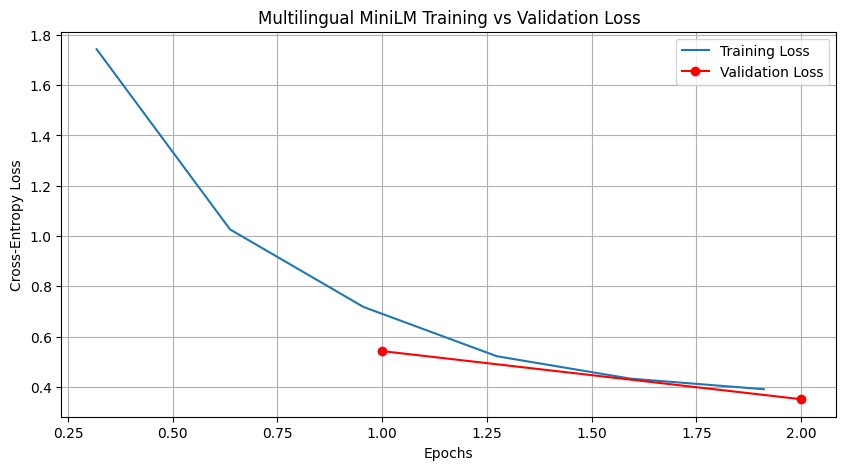

Generating Confusion Matrix on entire Validation Set...


<Figure size 1500x1500 with 0 Axes>

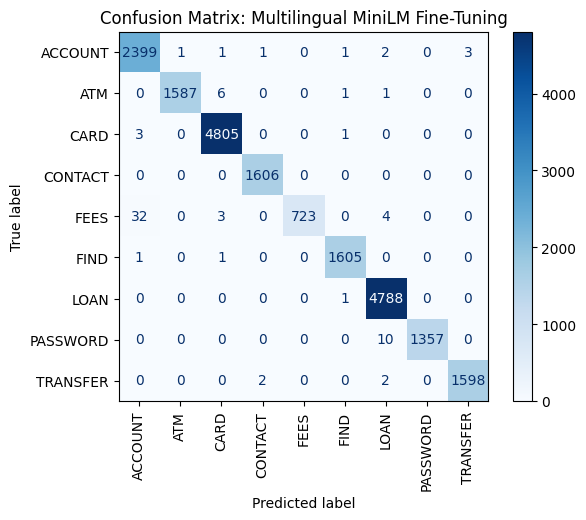

Extracting mismatched records...


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:

# 1. Load Data
print("Loading dataset...")
dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset", split="train")

# Set the official multilingual MiniLM model
define_model = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

# Create mappings (Using 'category' instead of 'intent')
intents = sorted(list(set(dataset['category'])))
id2label = {i: label for i, label in enumerate(intents)}
label2id = {label: i for i, label in enumerate(intents)}

# 2. Tokenization
print("Initializing MiniLM Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(define_model)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else tokenizer.unk_token

def preprocess(examples):
    examples['label'] = [label2id[i] for i in examples['category']]
    return tokenizer(examples['instruction'], truncation=True, padding='max_length', max_length=64)

# Apply preprocessing to the whole dataset first
print("Preprocessing dataset...")
tokenized_ds = dataset.map(preprocess, batched=True)

# --- STRATIFIED SPLIT LOGIC (FIXED) ---
print("Performing stratified split...")

# 1. CONVERT THE COLUMN TO ClassLabel (This fixes the ValueError!)
tokenized_ds = tokenized_ds.class_encode_column("label")

target_train_size = 5000
total_size = len(tokenized_ds)
test_size_ratio = (total_size - target_train_size) / total_size

# 2. Stratified split will now work perfectly
split_ds = tokenized_ds.train_test_split(
    test_size=test_size_ratio,
    stratify_by_column="label",
    seed=42
)

train_dataset = split_ds["train"]
val_dataset = split_ds["test"]

# Verification Step
train_categories = set(train_dataset['label'])
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Unique categories in Train Set: {len(train_categories)} out of {len(id2label)}")
assert len(train_categories) == len(id2label), "ERROR: Some categories were missed in the split!"
# ---------------------------------------------------------------------

# 3. Load Model
print("Loading Multilingual MiniLM Model...")
model = AutoModelForSequenceClassification.from_pretrained(
    define_model, 
    num_labels=len(intents), 
    id2label=id2label, 
    label2id=label2id,
    ignore_mismatched_sizes=True 
)

# 4. Training Arguments
training_args = TrainingArguments(
    output_dir="./multilingual_minilm_results",
    per_device_train_batch_size=32, 
    num_train_epochs=2,            
    eval_strategy="epoch",         
    logging_steps=50,             
    learning_rate=3e-5,            
    weight_decay=0.01,
    fp16=True,                     
)

# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # Proportional 5k rows
    eval_dataset=val_dataset,    # ~21.8k rows
)

# Train
print("Starting Multilingual MiniLM Training...")
trainer.train()

# 6. Loss Curve Visualization
print("Generating Loss Curves...")
history = trainer.state.log_history

train_losses = []
train_epochs = []
eval_losses = []
eval_epochs = []

for entry in history:
    if 'loss' in entry:
        train_losses.append(entry['loss'])
        train_epochs.append(entry['epoch'])
    if 'eval_loss' in entry:
        eval_losses.append(entry['eval_loss'])
        eval_epochs.append(entry['epoch'])

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_losses, label='Training Loss')
plt.plot(eval_epochs, eval_losses, label='Validation Loss', marker='o', color='red')
plt.title('Multilingual MiniLM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# 7. Confusion Matrix
print("Generating Confusion Matrix on entire Validation Set...")
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = val_dataset['label']

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=intents)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix: Multilingual MiniLM Fine-Tuning")
plt.show()

# --- EXTRACT ALL MISMATCHED RECORDS ---
print("Extracting mismatched records...")
mismatched_indices = np.where(labels != preds)[0]

mismatched_data = []
for idx in mismatched_indices:
    original_row = val_dataset[int(idx)]
    mismatched_data.append({
        "instruction": original_row['instruction'],
        "actual": id2label[original_row['label']],
        "predicted": id2label[preds[idx]]
    })

df_errors = pd.DataFrame(mismatched_data)
print(f"Total validation mismatches found: {len(df_errors)}")

if not df_errors.empty:
    df_errors.to_csv("val_mismatched_records.csv", index=False)
    print("Mismatched records saved to 'val_mismatched_records.csv'")
    print(df_errors.head(10).to_string())

# 8. Save Model
model.save_pretrained("./my_multilingual_minilm_model")
tokenizer.save_pretrained("./my_multilingual_minilm_model")
print("Model saved to './my_multilingual_minilm_model'")

In [6]:
# Convert both to 1D numpy arrays to ensure clean element-wise comparison
y_true = np.array(labels)
y_pred = np.array(preds)

# Find where they do not match
mismatched_indices = np.where(y_true != y_pred)[0]

mismatched_data = []
for idx in mismatched_indices:
    original_row = val_dataset[int(idx)]
    mismatched_data.append({
        "instruction": original_row['instruction'],
        "actual": id2label[original_row['label']],
        "predicted": id2label[y_pred[idx]] # Use the numpy array value
    })

df_errors = pd.DataFrame(mismatched_data)
print(f"Total validation mismatches found: {len(df_errors)}")


Total validation mismatches found: 77


In [7]:
df_errors

,instruction,actual,predicted
0,i have to get a passowrd where can i do it,PASSWORD,LOAN
1,can you help me rertieve an Amex?,ATM,CARD
2,"I would like to set up a passowrd, where can I...",PASSWORD,LOAN
3,"I can't find my fwe, will you help me check it?",FEES,ACCOUNT
4,i cannot find myfee i need assistance to see it,FEES,LOAN
...,...,...,...
72,"I cannot find my account fes, I need assistanc...",FEES,ACCOUNT
73,"I can't find my feex, check them",FEES,CARD
74,i do not have a passowrd,PASSWORD,LOAN
75,are there any fucking fee for my account,FEES,ACCOUNT
